# Visitor Count Forecasting (Sigiriya)

This notebook sets up the environment, explores the Sigiriya visitors dataset, fits a Holt–Winters model with weekly seasonality, forecasts daily visitors, and saves outputs.

We'll also include quick math formatting examples.

In [1]:
# Imports and environment checks
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
print({'python': sys.version, 'platform': platform.platform()})
print({'numpy': np.__version__, 'pandas': pd.__version__})
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

{'python': '3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]', 'platform': 'macOS-26.3-arm64-arm-64bit-Mach-O'}
{'numpy': '2.3.5', 'pandas': '2.3.3'}


In [2]:
# Simple Python cell demonstration
a = 21
b = 21
c = a + b
print('a:', a, 'b:', b, 'c:', c)

a: 21 b: 21 c: 42


# Math examples
Inline: $a^2 + b^2 = c^2$

Block: $$\int_0^1 x^2 \, dx = \frac{1}{3}$$

In [3]:
# Load and explore dataset
import os
csv_path = os.path.join(os.getcwd(), "sigiriya_synthetic_visitors_2023_2025.csv")
df = pd.read_csv(csv_path, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print('Rows:', len(df), '| Columns:', list(df.columns))
display(df.head())
display(df.describe(include='all'))
# handle missing values basic
df['Visitor_Count'] = df['Visitor_Count'].fillna(method='ffill').fillna(0)
df['Date'] = df['Date'].fillna(method='ffill')
# build daily series
s = df.set_index('Date')['Visitor_Count'].astype(float).asfreq('D')
print('Series start:', s.index.min(), '| end:', s.index.max(), '| length:', len(s))

Rows: 1085 | Columns: ['Date', 'Attraction', 'Avg_Temperature', 'Rainfall_mm', 'Public_Holiday_Count', 'Festival_Season', 'Foreign_Visitors_%', 'Visitor_Count']


,Date,Attraction,Avg_Temperature,Rainfall_mm,Public_Holiday_Count,Festival_Season,Foreign_Visitors_%,Visitor_Count
0,2023-01-01,Sigiriya Rock Fortress,26.5,7.4,1,New Year,68,5185
1,2023-01-02,Sigiriya Rock Fortress,25.7,1.1,0,Peak Season,67,3897
2,2023-01-03,Sigiriya Rock Fortress,26.8,8.6,0,Peak Season,70,3338
3,2023-01-04,Sigiriya Rock Fortress,26.9,11.8,0,Peak Season,68,3507
4,2023-01-05,Sigiriya Rock Fortress,25.2,14.1,0,Peak Season,67,3472


,Date,Attraction,Avg_Temperature,Rainfall_mm,Public_Holiday_Count,Festival_Season,Foreign_Visitors_%,Visitor_Count
count,1085,1085,1085.000000,1085.000000,1085.000000,452,1085.000000,1085.000000
unique,NaN,1,NaN,NaN,NaN,5,NaN,NaN
top,NaN,Sigiriya Rock Fortress,NaN,NaN,NaN,Peak Season,NaN,NaN
freq,NaN,1085,NaN,NaN,NaN,348,NaN,NaN
mean,2024-06-26 00:00:00,NaN,28.507373,13.501567,0.066359,NaN,53.222120,2986.117051
min,2023-01-01 00:00:00,NaN,24.900000,0.000000,0.000000,NaN,26.000000,974.000000
25%,2023-09-29 00:00:00,NaN,27.100000,3.500000,0.000000,NaN,45.000000,2399.000000
50%,2024-06-26 00:00:00,NaN,28.500000,8.000000,0.000000,NaN,52.000000,2914.000000
75%,2025-03-24 00:00:00,NaN,30.000000,16.000000,0.000000,NaN,61.000000,3517.000000
max,2025-12-20 00:00:00,NaN,32.100000,146.500000,1.000000,NaN,86.000000,5438.000000


Series start: 2023-01-01 00:00:00 | end: 2025-12-20 00:00:00 | length: 1085


/var/folders/5g/by988vg57qjcf_fcyzdnjyx40000gn/T/ipykernel_23148/3760037426.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Visitor_Count'] = df['Visitor_Count'].fillna(method='ffill').fillna(0)
/var/folders/5g/by988vg57qjcf_fcyzdnjyx40000gn/T/ipykernel_23148/3760037426.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Date'] = df['Date'].fillna(method='ffill')


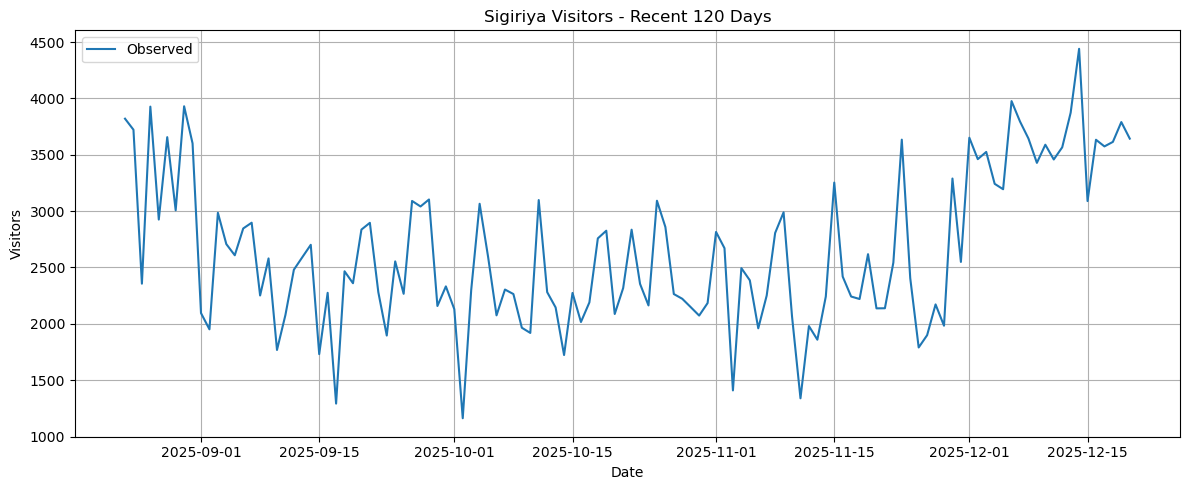

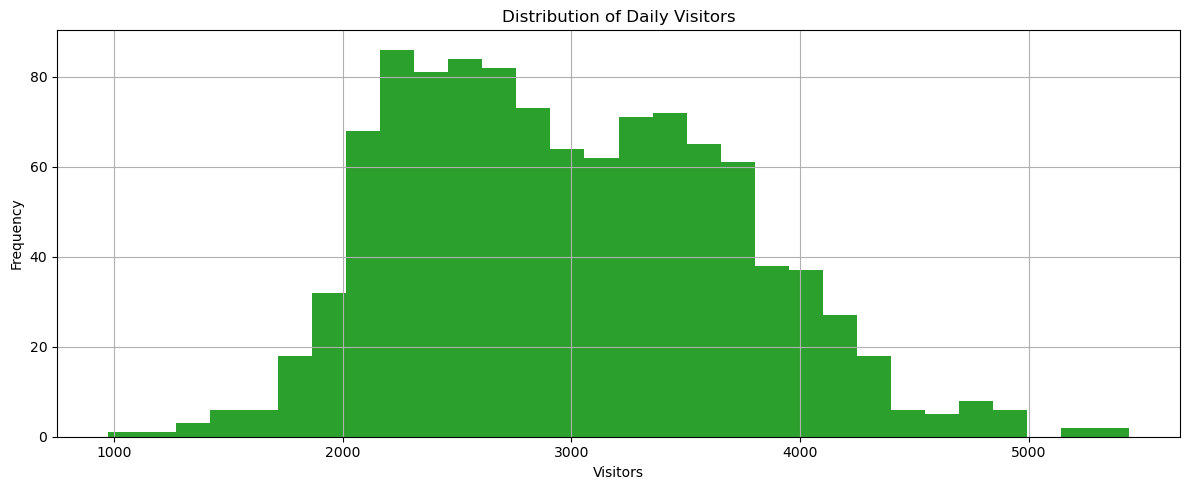

In [4]:
# Plot data inline
recent = s.tail(120)
plt.figure()
plt.plot(recent.index, recent.values, label='Observed', color='#1f77b4')
plt.title('Sigiriya Visitors - Recent 120 Days')
plt.xlabel('Date')
plt.ylabel('Visitors')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(s.values, bins=30, color='#2ca02c')
plt.title('Distribution of Daily Visitors')
plt.xlabel('Visitors')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Saved: forecast_output.csv


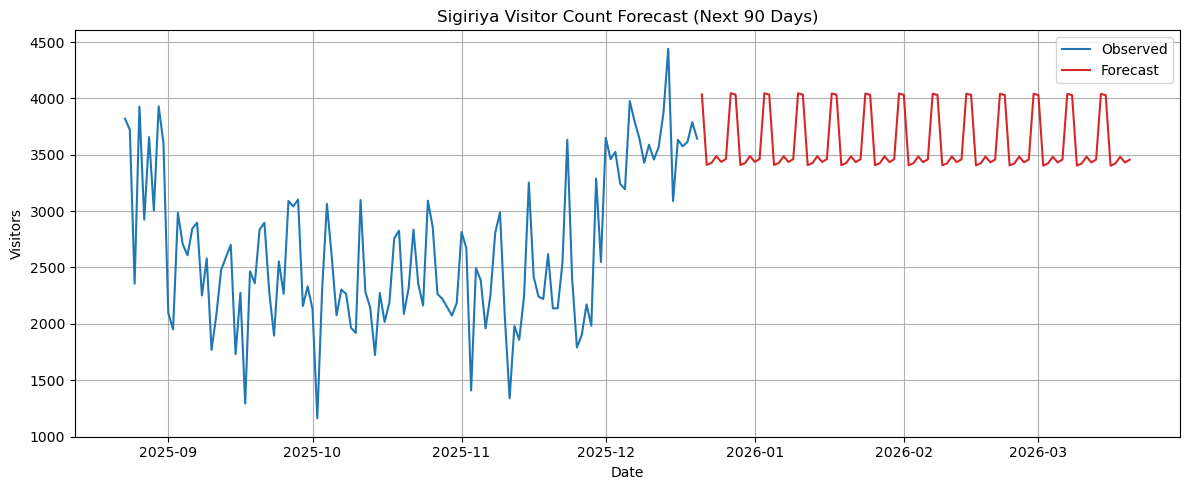

Saved: forecast_plot.png


,Date,Forecast_Visitor_Count
2025-12-21,2025-12-21,4035
2025-12-22,2025-12-22,3410
2025-12-23,2025-12-23,3428
2025-12-24,2025-12-24,3488
2025-12-25,2025-12-25,3437


In [5]:
# Forecast with Holt–Winters (weekly seasonality) and save outputs
import numpy as np
from datetime import timedelta
model = ExponentialSmoothing(s, trend='add', seasonal='add', seasonal_periods=7)
res = model.fit(optimized=True, use_brute=True)
horizon = 90
fc_vals = res.forecast(horizon)
future_index = pd.date_range(s.index.max() + pd.Timedelta(days=1), periods=horizon, freq='D')
fc_df = pd.DataFrame({'Date': future_index, 'Forecast_Visitor_Count': np.maximum(fc_vals, 0)})
fc_df['Forecast_Visitor_Count'] = fc_df['Forecast_Visitor_Count'].round().astype(int)
out_csv = 'forecast_output.csv'
out_plot = 'forecast_plot.png'
fc_df.to_csv(out_csv, index=False)
print('Saved:', out_csv)
plt.figure()
plt.plot(s.tail(120).index, s.tail(120).values, label='Observed', color='#1f77b4')
plt.plot(fc_df['Date'], fc_df['Forecast_Visitor_Count'].values, label='Forecast', color='#d62728')
plt.title('Sigiriya Visitor Count Forecast (Next 90 Days)')
plt.xlabel('Date')
plt.ylabel('Visitors')
plt.legend()
plt.tight_layout()
plt.savefig(out_plot)
plt.show()
print('Saved:', out_plot)
display(fc_df.head())

In [6]:
# Optional: Export notebook to HTML using nbconvert
try:
    import nbconvert, nbformat, os
    nb_path = os.path.abspath('visitor_forecast.ipynb')
    exporter = nbconvert.HTMLExporter()
    exporter.exclude_input_prompt = True
    exporter.exclude_output_prompt = True
    with open(nb_path, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)
    (body, resources) = exporter.from_notebook_node(nb)
    with open('visitor_forecast.html', 'w', encoding='utf-8') as f:
        f.write(body)
    print('Exported to visitor_forecast.html')
except Exception as e:
    print('Export skipped. To enable, install nbconvert & nbformat:', e)

Exported to visitor_forecast.html


17:30:32 - cmdstanpy - INFO - Chain [1] start processing
17:30:33 - cmdstanpy - INFO - Chain [1] done processing


Saved: prophet_forecast_output.csv
Saved: prophet_forecast_plot.png
Saved: prophet_components_plot.png


,Date,Forecast_Visitor_Count
1085,2025-12-21,4049
1086,2025-12-22,3510
1087,2025-12-23,3447
1088,2025-12-24,3473
1089,2025-12-25,3296


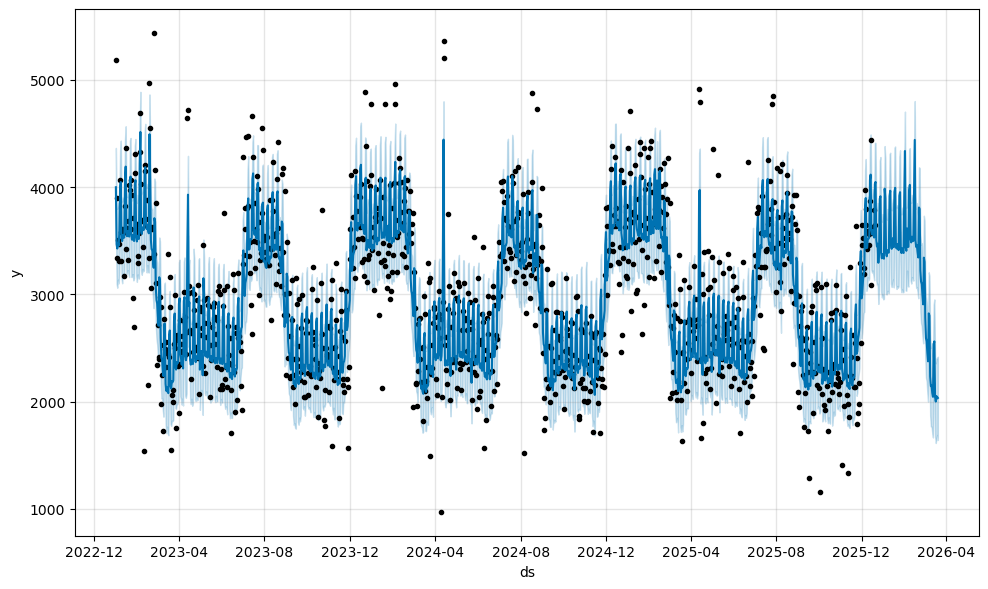

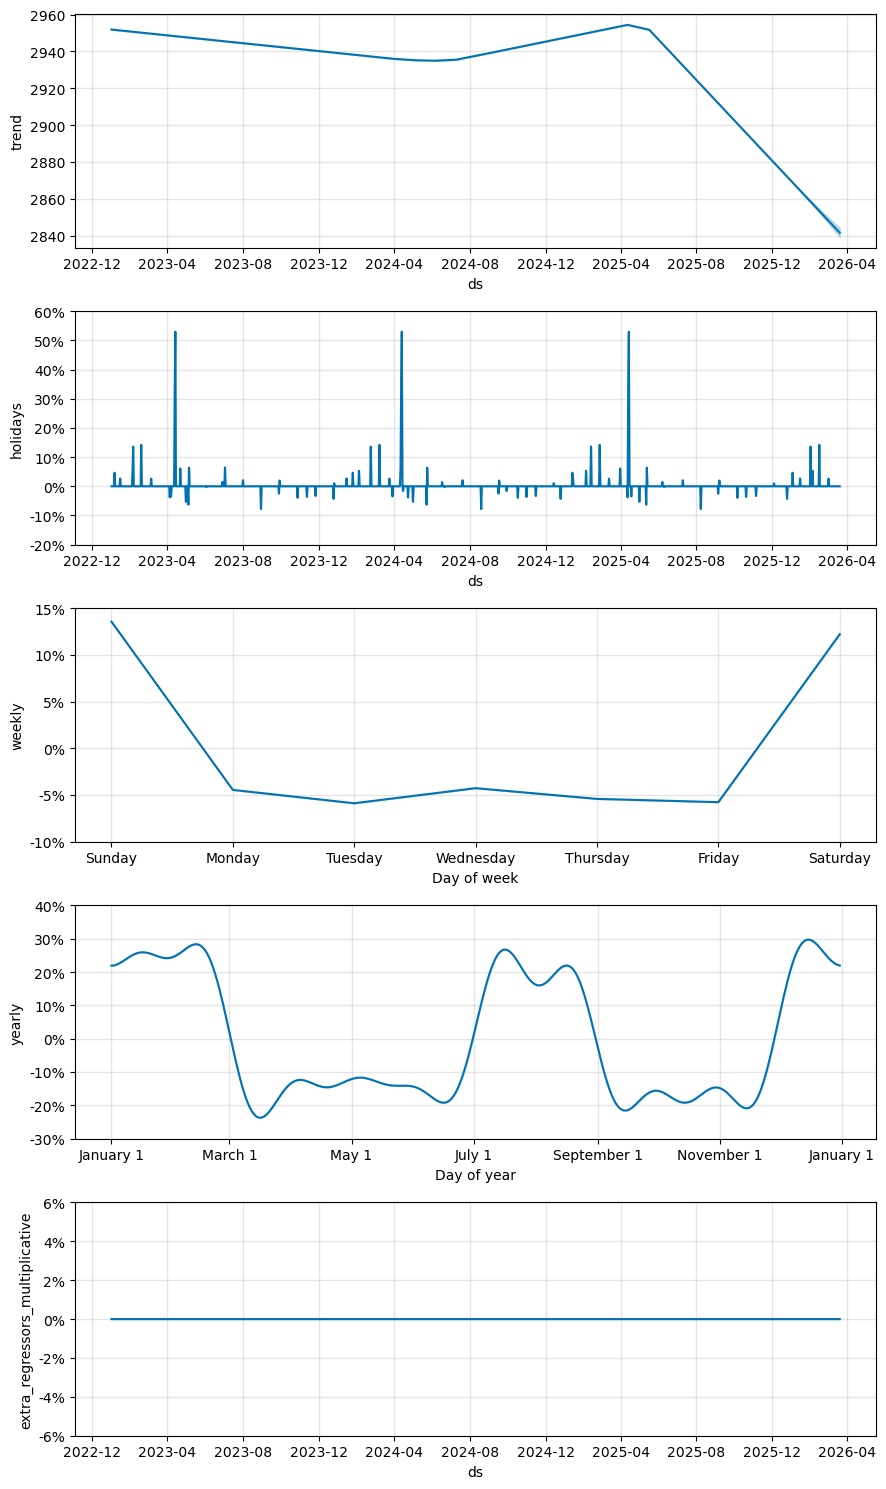

In [7]:
# Prophet forecasting (enhanced with yearly seasonality, holidays, and regressors)
from prophet import Prophet
import pandas as pd
import numpy as np

# Prepare data for Prophet: columns ds (date), y (value) + regressors
df_p = df[['Date', 'Visitor_Count', 'Avg_Temperature', 'Rainfall_mm', 'Public_Holiday_Count']].copy()
df_p.columns = ['ds', 'y', 'temperature', 'rainfall', 'public_holiday']

# Initialize Prophet with enhanced configuration
m = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,  # Enable yearly patterns
    daily_seasonality=False,
    changepoint_prior_scale=0.05,  # More flexible trend
    seasonality_prior_scale=10.0,  # Stronger seasonality
    seasonality_mode='multiplicative'  # Better for tourism data
)

# Add Sri Lanka holidays
m.add_country_holidays(country_name='LK')

# Add regressors for weather and holidays
m.add_regressor('temperature')
m.add_regressor('rainfall')
m.add_regressor('public_holiday')

m.fit(df_p)

# Forecast future: need to provide regressor values
horizon = 90
future = m.make_future_dataframe(periods=horizon, freq='D')

# Use recent averages for future regressors
future['temperature'] = df_p['temperature'].mean()
future['rainfall'] = df_p['rainfall'].mean()
future['public_holiday'] = 0  # Assume no holidays in forecast period

forecast = m.predict(future)

# Save next horizon predictions
fc_prophet = forecast.tail(horizon)[['ds','yhat']]
fc_prophet = fc_prophet.rename(columns={'ds':'Date','yhat':'Forecast_Visitor_Count'})
fc_prophet['Forecast_Visitor_Count'] = np.maximum(fc_prophet['Forecast_Visitor_Count'], 0).round().astype(int)
out_csv_p = 'prophet_forecast_output.csv'
fc_prophet.to_csv(out_csv_p, index=False)
print('Saved:', out_csv_p)

# Plot and save
fig = m.plot(forecast)
fig.savefig('prophet_forecast_plot.png')
print('Saved: prophet_forecast_plot.png')

# Plot components
fig2 = m.plot_components(forecast)
fig2.savefig('prophet_components_plot.png')
print('Saved: prophet_components_plot.png')

fc_prophet.head()

In [8]:
# MAE comparison: Holt-Winters vs Enhanced Prophet on last 30 days
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Split data: train on all except last 30 days, test on last 30
test_size = 30
train_idx = len(df) - test_size
train_df = df[:train_idx].copy()
test_df = df[train_idx:].copy()

train = s[:-test_size]
test = s[-test_size:]

print(f'Train: {train.index.min()} to {train.index.max()} ({len(train)} days)')
print(f'Test: {test.index.min()} to {test.index.max()} ({test_size} days)\n')

# --- Holt-Winters forecast ---
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7)
hw_res = hw_model.fit(optimized=True, use_brute=True)
hw_forecast = hw_res.forecast(test_size)
hw_mae = mean_absolute_error(test, hw_forecast)
hw_mape = mean_absolute_percentage_error(test, hw_forecast) * 100

# --- Enhanced Prophet forecast ---
train_df_p = train_df[['Date', 'Visitor_Count', 'Avg_Temperature', 'Rainfall_mm', 'Public_Holiday_Count']].copy()
train_df_p.columns = ['ds', 'y', 'temperature', 'rainfall', 'public_holiday']

prophet_m = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    seasonality_mode='multiplicative'
)
prophet_m.add_country_holidays(country_name='LK')
prophet_m.add_regressor('temperature')
prophet_m.add_regressor('rainfall')
prophet_m.add_regressor('public_holiday')
prophet_m.fit(train_df_p)

# Create future dataframe with actual test regressors
future_test = test_df[['Date', 'Avg_Temperature', 'Rainfall_mm', 'Public_Holiday_Count']].copy()
future_test.columns = ['ds', 'temperature', 'rainfall', 'public_holiday']
prophet_fc = prophet_m.predict(future_test)
prophet_forecast = prophet_fc['yhat'].values
prophet_mae = mean_absolute_error(test, prophet_forecast)
prophet_mape = mean_absolute_percentage_error(test, prophet_forecast) * 100

# Results
results = pd.DataFrame({
    'Model': ['Holt-Winters', 'Prophet (Enhanced)'],
    'MAE': [hw_mae, prophet_mae],
    'MAPE (%)': [hw_mape, prophet_mape]
})

print(results.to_string(index=False))
print(f'\nBest MAE: {results.loc[results["MAE"].idxmin(), "Model"]}')

17:30:34 - cmdstanpy - INFO - Chain [1] start processing


Train: 2023-01-01 00:00:00 to 2025-11-20 00:00:00 (1055 days)
Test: 2025-11-21 00:00:00 to 2025-12-20 00:00:00 (30 days)



17:30:34 - cmdstanpy - INFO - Chain [1] done processing


             Model        MAE  MAPE (%)
      Holt-Winters 936.682542 27.078293
Prophet (Enhanced) 320.183479 11.204964

Best MAE: Prophet (Enhanced)


In [9]:
def save_prophet_forecast(
    df,
    date_col='Date',
    target_col='Visitor_Count',
    regressor_cols=None,
    horizon=90,
    output_csv='prophet_forecast.csv',
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
    add_holidays=True,
    country='LK',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    seasonality_mode='multiplicative'
):
    """
    Fit Prophet model and save forecast to CSV.
    
    Parameters:
    -----------
    df : DataFrame
        Input data with date, target, and optional regressors
    date_col : str
        Name of the date column
    target_col : str
        Name of the target variable column
    regressor_cols : list or None
        List of regressor column names (e.g., ['temperature', 'rainfall'])
    horizon : int
        Number of periods to forecast
    output_csv : str
        Output CSV file path
    weekly_seasonality : bool
        Enable weekly seasonality
    yearly_seasonality : bool
        Enable yearly seasonality
    daily_seasonality : bool
        Enable daily seasonality
    add_holidays : bool
        Add country holidays
    country : str
        Country code for holidays (e.g., 'LK' for Sri Lanka)
    changepoint_prior_scale : float
        Flexibility of trend changes
    seasonality_prior_scale : float
        Strength of seasonality
    seasonality_mode : str
        'additive' or 'multiplicative'
    
    Returns:
    --------
    tuple : (forecast_df, prophet_model, full_forecast)
    """
    from prophet import Prophet
    import pandas as pd
    import numpy as np
    
    # Prepare data for Prophet
    cols_to_select = [date_col, target_col]
    if regressor_cols:
        cols_to_select.extend(regressor_cols)
    
    df_prophet = df[cols_to_select].copy()
    col_mapping = {date_col: 'ds', target_col: 'y'}
    df_prophet = df_prophet.rename(columns=col_mapping)
    
    # Initialize Prophet
    m = Prophet(
        weekly_seasonality=weekly_seasonality,
        yearly_seasonality=yearly_seasonality,
        daily_seasonality=daily_seasonality,
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        seasonality_mode=seasonality_mode
    )
    
    # Add holidays
    if add_holidays and country:
        m.add_country_holidays(country_name=country)
    
    # Add regressors
    if regressor_cols:
        for reg in regressor_cols:
            m.add_regressor(reg)
    
    # Fit model
    m.fit(df_prophet)
    
    # Create future dataframe
    future = m.make_future_dataframe(periods=horizon, freq='D')
    
    # Add regressor values for future dates
    if regressor_cols:
        for reg in regressor_cols:
            # Use mean of historical data for future
            future[reg] = df_prophet[reg].mean()
    
    # Predict
    forecast = m.predict(future)
    
    # Extract forecast for future periods only
    fc_df = forecast.tail(horizon)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    fc_df = fc_df.rename(columns={
        'ds': 'Date',
        'yhat': 'Forecast_Visitor_Count',
        'yhat_lower': 'Lower_Bound',
        'yhat_upper': 'Upper_Bound'
    })
    
    # Clamp negative values to zero and round
    fc_df['Forecast_Visitor_Count'] = np.maximum(fc_df['Forecast_Visitor_Count'], 0).round().astype(int)
    fc_df['Lower_Bound'] = np.maximum(fc_df['Lower_Bound'], 0).round().astype(int)
    fc_df['Upper_Bound'] = np.maximum(fc_df['Upper_Bound'], 0).round().astype(int)
    
    # Save to CSV
    fc_df.to_csv(output_csv, index=False)
    print(f'✓ Saved forecast to: {output_csv}')
    print(f'  - Periods: {horizon} days')
    print(f'  - Date range: {fc_df["Date"].min()} to {fc_df["Date"].max()}')
    print(f'  - Avg forecast: {fc_df["Forecast_Visitor_Count"].mean():.0f} visitors/day')
    
    return fc_df, m, forecast

In [10]:
# Example: Use the function to generate forecast
fc_df, prophet_model, full_forecast = save_prophet_forecast(
    df=df,
    date_col='Date',
    target_col='Visitor_Count',
    regressor_cols=['Avg_Temperature', 'Rainfall_mm', 'Public_Holiday_Count'],
    horizon=90,
    output_csv='prophet_forecast_function_output.csv',
    weekly_seasonality=True,
    yearly_seasonality=True,
    add_holidays=True,
    country='LK'
)

# Display preview
display(fc_df.head(10))
display(fc_df.tail(10))

17:30:34 - cmdstanpy - INFO - Chain [1] start processing
17:30:34 - cmdstanpy - INFO - Chain [1] done processing


✓ Saved forecast to: prophet_forecast_function_output.csv
  - Periods: 90 days
  - Date range: 2025-12-21 00:00:00 to 2026-03-20 00:00:00
  - Avg forecast: 3340 visitors/day


,Date,Forecast_Visitor_Count,Lower_Bound,Upper_Bound
1085,2025-12-21,4095,3707,4474
1086,2025-12-22,3556,3215,3925
1087,2025-12-23,3493,3122,3862
1088,2025-12-24,3518,3163,3878
1089,2025-12-25,3341,2961,3705
1090,2025-12-26,3436,3076,3807
1091,2025-12-27,3936,3557,4292
1092,2025-12-28,3961,3587,4350
1093,2025-12-29,3432,3045,3789
1094,2025-12-30,3382,3012,3748


,Date,Forecast_Visitor_Count,Lower_Bound,Upper_Bound
1165,2026-03-11,2195,1836,2567
1166,2026-03-12,2128,1759,2500
1167,2026-03-13,2091,1736,2445
1168,2026-03-14,2582,2201,2955
1169,2026-03-15,2608,2249,2955
1170,2026-03-16,2088,1703,2449
1171,2026-03-17,2047,1683,2410
1172,2026-03-18,2098,1698,2499
1173,2026-03-19,2076,1715,2436
1174,2026-03-20,2080,1707,2451


In [11]:
def suggest_visiting_times(
    forecast_df,
    date_col='Date',
    visitor_col='Forecast_Visitor_Count',
    crowded_threshold=0.75,
    best_days_count=10,
    worst_days_count=10,
    check_date=None
):
    """
    Analyze forecast to suggest best visiting times and warn about crowded periods.
    
    Parameters:
    -----------
    forecast_df : DataFrame
        Forecast data with dates and visitor counts
    date_col : str
        Name of the date column
    visitor_col : str
        Name of the visitor count column
    crowded_threshold : float
        Percentile threshold for crowded days (0.75 = top 25%)
    best_days_count : int
        Number of best days to return
    worst_days_count : int
        Number of worst (most crowded) days to return
    check_date : str or datetime
        Specific date to check (defaults to today)
    
    Returns:
    --------
    dict : Analysis results with recommendations
    """
    import pandas as pd
    import numpy as np
    from datetime import datetime
    
    df = forecast_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Calculate statistics
    mean_visitors = df[visitor_col].mean()
    median_visitors = df[visitor_col].median()
    std_visitors = df[visitor_col].std()
    crowded_cutoff = df[visitor_col].quantile(crowded_threshold)
    
    # Add day of week
    df['day_name'] = df[date_col].dt.day_name()
    df['is_weekend'] = df[date_col].dt.dayofweek.isin([5, 6])
    
    # Classify crowd levels
    df['crowd_level'] = pd.cut(
        df[visitor_col],
        bins=[0, mean_visitors * 0.7, mean_visitors * 1.3, np.inf],
        labels=['Low', 'Moderate', 'High']
    )
    
    # Best days (least crowded)
    best_days = df.nsmallest(best_days_count, visitor_col)[[date_col, visitor_col, 'day_name', 'crowd_level']].copy()
    
    # Worst days (most crowded)
    worst_days = df.nlargest(worst_days_count, visitor_col)[[date_col, visitor_col, 'day_name', 'crowd_level']].copy()
    
    # Check specific date
    today_info = None
    if check_date:
        check_date = pd.to_datetime(check_date)
    else:
        check_date = pd.Timestamp.today().normalize()
    
    today_match = df[df[date_col] == check_date]
    if not today_match.empty:
        today_visitors = today_match[visitor_col].iloc[0]
        today_day = today_match['day_name'].iloc[0]
        today_level = today_match['crowd_level'].iloc[0]
        
        is_crowded = today_visitors >= crowded_cutoff
        percent_vs_avg = ((today_visitors - mean_visitors) / mean_visitors) * 100
        
        today_info = {
            'date': check_date,
            'day': today_day,
            'expected_visitors': int(today_visitors),
            'crowd_level': today_level,
            'is_crowded': is_crowded,
            'percent_vs_average': round(percent_vs_avg, 1),
            'average_visitors': round(mean_visitors, 0)
        }
    
    # Day of week patterns
    dow_stats = df.groupby('day_name')[visitor_col].agg(['mean', 'min', 'max']).round(0)
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_stats = dow_stats.reindex([d for d in dow_order if d in dow_stats.index])
    
    results = {
        'statistics': {
            'mean': round(mean_visitors, 0),
            'median': round(median_visitors, 0),
            'std': round(std_visitors, 0),
            'crowded_threshold': round(crowded_cutoff, 0)
        },
        'best_days': best_days,
        'worst_days': worst_days,
        'today': today_info,
        'day_of_week_patterns': dow_stats
    }
    
    return results


def print_visiting_recommendations(analysis):
    """
    Print user-friendly recommendations from analysis results.
    """
    import pandas as pd
    
    print("=" * 60)
    print("🏛️  SIGIRIYA VISITOR FORECAST RECOMMENDATIONS")
    print("=" * 60)
    
    # Today's status
    if analysis['today']:
        t = analysis['today']
        print(f"\n📅 TODAY: {t['date'].strftime('%B %d, %Y')} ({t['day']})")
        print(f"   Expected Visitors: {t['expected_visitors']:,}")
        print(f"   Crowd Level: {t['crowd_level']}")
        
        if t['is_crowded']:
            print(f"   ⚠️  WARNING: HIGH CROWD EXPECTED!")
            print(f"   Today is {abs(t['percent_vs_average']):.0f}% above average")
            print(f"   Consider visiting on a less crowded day below.")
        else:
            if t['percent_vs_average'] < -10:
                print(f"   ✅ GOOD TIME TO VISIT!")
                print(f"   Today is {abs(t['percent_vs_average']):.0f}% below average")
            else:
                print(f"   ✓ Moderate crowd expected")
    else:
        print("\n📅 TODAY: Not in forecast period")
    
    # Best days
    print(f"\n✨ BEST TIMES TO VISIT (Least Crowded):")
    print("-" * 60)
    for idx, row in analysis['best_days'].head(5).iterrows():
        date_str = pd.to_datetime(row[analysis['best_days'].columns[0]]).strftime('%b %d, %Y (%a)')
        visitors = row[analysis['best_days'].columns[1]]
        print(f"   • {date_str}: ~{visitors:,} visitors")
    
    # Worst days
    print(f"\n🚫 DAYS TO AVOID (Most Crowded):")
    print("-" * 60)
    for idx, row in analysis['worst_days'].head(5).iterrows():
        date_str = pd.to_datetime(row[analysis['worst_days'].columns[0]]).strftime('%b %d, %Y (%a)')
        visitors = row[analysis['worst_days'].columns[1]]
        print(f"   • {date_str}: ~{visitors:,} visitors")
    
    # Day of week patterns
    print(f"\n📊 AVERAGE BY DAY OF WEEK:")
    print("-" * 60)
    for day, stats in analysis['day_of_week_patterns'].iterrows():
        avg = stats['mean']
        print(f"   {day:9s}: ~{avg:,.0f} visitors (range: {stats['min']:.0f} - {stats['max']:.0f})")
    
    # General tips
    print(f"\n💡 GENERAL TIPS:")
    print("-" * 60)
    avg = analysis['statistics']['mean']
    best_dow = analysis['day_of_week_patterns']['mean'].idxmin()
    worst_dow = analysis['day_of_week_patterns']['mean'].idxmax()
    
    print(f"   • Average daily visitors: {avg:,.0f}")
    print(f"   • Quietest day of week: {best_dow}")
    print(f"   • Busiest day of week: {worst_dow}")
    print(f"   • Consider early morning visits for better experience")
    print("=" * 60)

In [12]:
# Example: Analyze forecast and get recommendations
analysis = suggest_visiting_times(
    forecast_df=fc_df,
    date_col='Date',
    visitor_col='Forecast_Visitor_Count',
    crowded_threshold=0.75,
    best_days_count=10,
    worst_days_count=10,
    check_date='2025-12-21'  # Check tomorrow
)

# Print user-friendly recommendations
print_visiting_recommendations(analysis)

🏛️  SIGIRIYA VISITOR FORECAST RECOMMENDATIONS

📅 TODAY: December 21, 2025 (Sunday)
   Expected Visitors: 4,095
   Crowd Level: Moderate
   ⚠️  WARNING: HIGH CROWD EXPECTED!
   Today is 23% above average
   Consider visiting on a less crowded day below.

✨ BEST TIMES TO VISIT (Least Crowded):
------------------------------------------------------------
   • Mar 17, 2026 (Tue): ~2,047 visitors
   • Mar 19, 2026 (Thu): ~2,076 visitors
   • Mar 20, 2026 (Fri): ~2,080 visitors
   • Mar 16, 2026 (Mon): ~2,088 visitors
   • Mar 13, 2026 (Fri): ~2,091 visitors

🚫 DAYS TO AVOID (Most Crowded):
------------------------------------------------------------
   • Feb 15, 2026 (Sun): ~4,486 visitors
   • Feb 01, 2026 (Sun): ~4,383 visitors
   • Dec 21, 2025 (Sun): ~4,095 visitors
   • Feb 08, 2026 (Sun): ~4,067 visitors
   • Feb 14, 2026 (Sat): ~4,052 visitors

📊 AVERAGE BY DAY OF WEEK:
------------------------------------------------------------
   Monday   : ~3,230 visitors (range: 2088 - 3563)
   

In [13]:
# Quick check for specific dates
from datetime import datetime

# Check today (if in forecast period)
print("🔍 QUICK CHECK FOR SPECIFIC DATES:")
print("=" * 60)

dates_to_check = ['2025-12-25', '2026-01-01', '2026-02-15']

for date_str in dates_to_check:
    result = suggest_visiting_times(
        forecast_df=fc_df,
        check_date=date_str
    )
    
    if result['today']:
        t = result['today']
        status = "🔴 CROWDED" if t['is_crowded'] else "🟢 GOOD" if t['percent_vs_average'] < -10 else "🟡 MODERATE"
        print(f"\n{status} {t['date'].strftime('%b %d, %Y')} ({t['day']})")
        print(f"   Expected: {t['expected_visitors']:,} visitors")
        print(f"   {t['percent_vs_average']:+.0f}% vs average ({t['average_visitors']:.0f})")
    else:
        print(f"\n❌ {date_str}: Not in forecast period")

🔍 QUICK CHECK FOR SPECIFIC DATES:

🟡 MODERATE Dec 25, 2025 (Thursday)
   Expected: 3,341 visitors
   +0% vs average (3340)

🟡 MODERATE Jan 01, 2026 (Thursday)
   Expected: 3,388 visitors
   +1% vs average (3340)

🔴 CROWDED Feb 15, 2026 (Sunday)
   Expected: 4,486 visitors
   +34% vs average (3340)


In [14]:
def chat_visitor_forecast(user_message, forecast_df, df_historical=None):
    """
    Conversational chat interface for visitor forecast queries.
    
    Parameters:
    -----------
    user_message : str
        User's natural language query (e.g., "Is 2025-12-25 good to visit?" or "What are the best dates?")
    forecast_df : DataFrame
        Forecast data with dates and visitor counts
    df_historical : DataFrame or None
        Historical data for comparison context
    
    Returns:
    --------
    str : Conversational response with recommendations
    """
    import pandas as pd
    import re
    from datetime import datetime, timedelta
    
    # Check if user is asking about best dates
    best_date_keywords = r'(best|quiet|least crowded|least busy|uncrowded|empty|when is best|optimal|good time|suggest.*date)'
    if re.search(best_date_keywords, user_message, re.IGNORECASE):
        return get_best_dates_response(forecast_df)
    
    # Extract date from user message
    date_pattern = r'(\d{4}-\d{2}-\d{2}|(\d{1,2}[-/]\d{1,2}[-/]\d{2,4})|(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]* \d{1,2}[,\s]+\d{4}?|\d{4})'
    dates_found = re.findall(date_pattern, user_message, re.IGNORECASE)
    
    # Try to parse dates
    check_date = None
    for date_match in dates_found:
        date_str = date_match[0] if isinstance(date_match, tuple) else date_match
        try:
            check_date = pd.to_datetime(date_str)
            break
        except:
            pass
    
    # If no date found, ask for clarification
    if check_date is None or pd.isna(check_date):
        return "I'd love to help! 😊 Could you please tell me a specific date? (e.g., '2025-12-25' or 'Dec 25, 2025') Or ask me 'What are the best dates to visit?'"
    
    # Analyze the forecast for that date
    analysis = suggest_visiting_times(forecast_df, check_date=check_date)
    
    # If date not in forecast
    if analysis['today'] is None:
        min_date = pd.to_datetime(forecast_df['Date'].iloc[0]).strftime('%B %d, %Y')
        max_date = pd.to_datetime(forecast_df['Date'].iloc[-1]).strftime('%B %d, %Y')
        return f"❌ Sorry! The date {check_date.strftime('%B %d, %Y')} is outside my forecast period. Please choose a date between {min_date} and {max_date}."
    
    t = analysis['today']
    
    # Build conversational response
    response = ""
    
    # Determine crowd status
    if t['is_crowded']:
        emoji = "🔴"
        sentiment = "might be crowded"
        warning = True
    elif t['percent_vs_average'] < -15:
        emoji = "🟢"
        sentiment = "is a great time to visit"
        warning = False
    else:
        emoji = "🟡"
        sentiment = "is moderately busy"
        warning = False
    
    # Main response
    response += f"{emoji} **{t['date'].strftime('%B %d, %Y')} ({t['day']})** {sentiment}!\n\n"
    
    # Details
    response += f"📊 **Expected Visitors:** ~{t['expected_visitors']:,} people\n"
    response += f"📈 **vs. Average:** {t['percent_vs_average']:+.0f}% ({t['average_visitors']:.0f} is typical)\n"
    response += f"🚦 **Crowd Level:** {t['crowd_level']}\n"
    
    # Recommendations
    if warning:
        response += f"\n⚠️ **Heads up!** This day is {abs(t['percent_vs_average']):.0f}% busier than usual. "
        response += f"You might have long queues and crowded pathways.\n\n"
        
        # Suggest alternatives
        response += "**✨ Better alternatives (less crowded):**\n"
        for idx, (_, row) in enumerate(analysis['best_days'].head(3).iterrows(), 1):
            date_str = pd.to_datetime(row['Date']).strftime('%b %d, %Y (%a)')
            visitors = row['Forecast_Visitor_Count']
            response += f"  {idx}. **{date_str}** → ~{visitors:,} visitors\n"
    else:
        response += f"\n✅ **You're in luck!** It's {abs(t['percent_vs_average']):.0f}% quieter than average. Perfect for exploring! 🎉\n"
    
    # Weekly pattern insight
    dow_stats = analysis['day_of_week_patterns']
    dow_avg = dow_stats.loc[t['day'], 'mean']
    dow_rank = pd.Series(dow_stats['mean']).rank()
    dow_rank = dow_rank[t['day']]
    total_days = len(dow_stats)
    
    response += f"\n📅 **Day of Week Insight:** {t['day']}s are the #{int(dow_rank)} {'busiest' if dow_rank > total_days/2 else 'quietest'} day of the week\n"
    response += f"   (Average: ~{dow_avg:,.0f} visitors)\n"
    
    return response


def get_best_dates_response(forecast_df):
    """
    Generate a response showing the best (least crowded) dates to visit.
    """
    import pandas as pd
    
    analysis = suggest_visiting_times(forecast_df, check_date=None)
    
    response = "✨ **TOP 10 BEST DATES TO VISIT (Least Crowded)** ✨\n\n"
    response += "Here are the quietest days in the forecast period:\n\n"
    
    for idx, (_, row) in enumerate(analysis['best_days'].head(10).iterrows(), 1):
        date_obj = pd.to_datetime(row[analysis['best_days'].columns[0]])
        date_str = date_obj.strftime('%b %d, %Y (%A)')
        visitors = int(row[analysis['best_days'].columns[1]])
        crowd = row[analysis['best_days'].columns[3]]
        
        # Calculate vs average
        avg = analysis['statistics']['mean']
        pct_vs_avg = ((visitors - avg) / avg) * 100
        
        response += f"{idx:2d}. 🟢 **{date_str}**\n"
        response += f"     Expected: ~{visitors:,} visitors ({pct_vs_avg:+.0f}% vs avg)\n"
        response += f"     Crowd: {crowd}\n\n"
    
    # Day of week summary
    response += "📅 **BEST DAYS OF THE WEEK (Overall)**\n"
    response += "-" * 50 + "\n"
    dow_stats = analysis['day_of_week_patterns'].sort_values('mean')
    for idx, (day, stats) in enumerate(dow_stats.iterrows(), 1):
        avg = stats['mean']
        response += f"{idx}. **{day}** → ~{avg:,.0f} visitors (range: {stats['min']:.0f}-{stats['max']:.0f})\n"
    
    response += f"\n💡 **Tip:** Mid-March weekdays (especially Tuesdays-Fridays) are your best bet for fewer crowds!\n"
    
    return response

In [15]:
# Demo: Test the chat interface with example queries
print("=" * 70)
print("DEMO: Conversational Chat Examples")
print("=" * 70)

test_queries = [
    "What are the best dates to visit?",
    "Is 2025-12-25 good to visit?",
    "Should I go on January 15, 2026?",
    "When is the best time to go?",
    "Is 2026-03-10 crowded?"
]

for query in test_queries:
    print(f"\n👤 You: {query}")
    print(f"\n🤖 Assistant:\n{chat_visitor_forecast(query, fc_df)}")
    print("\n" + "-" * 70)

DEMO: Conversational Chat Examples

👤 You: What are the best dates to visit?

🤖 Assistant:
✨ **TOP 10 BEST DATES TO VISIT (Least Crowded)** ✨

Here are the quietest days in the forecast period:

 1. 🟢 **Mar 17, 2026 (Tuesday)**
     Expected: ~2,047 visitors (-39% vs avg)
     Crowd: Low

 2. 🟢 **Mar 19, 2026 (Thursday)**
     Expected: ~2,076 visitors (-38% vs avg)
     Crowd: Low

 3. 🟢 **Mar 20, 2026 (Friday)**
     Expected: ~2,080 visitors (-38% vs avg)
     Crowd: Low

 4. 🟢 **Mar 16, 2026 (Monday)**
     Expected: ~2,088 visitors (-37% vs avg)
     Crowd: Low

 5. 🟢 **Mar 13, 2026 (Friday)**
     Expected: ~2,091 visitors (-37% vs avg)
     Crowd: Low

 6. 🟢 **Mar 18, 2026 (Wednesday)**
     Expected: ~2,098 visitors (-37% vs avg)
     Crowd: Low

 7. 🟢 **Mar 12, 2026 (Thursday)**
     Expected: ~2,128 visitors (-36% vs avg)
     Crowd: Low

 8. 🟢 **Mar 10, 2026 (Tuesday)**
     Expected: ~2,190 visitors (-34% vs avg)
     Crowd: Low

 9. 🟢 **Mar 11, 2026 (Wednesday)**
     Expe